English Premier League Match Data Analysis


# English Premier League Match Outcome Prediction

This notebook explores historical English Premier League (EPL) match data and builds a simple machine learning model to predict full-time match results based on in-game statistics.

The objective is to demonstrate data analysis, visualization, and baseline modeling on a real-world sports dataset.



## Dataset

Source: Kaggle — English Premier League Match Data (2000–2025)

Each row represents a single EPL match.

Target variable:
- **FullTimeResult**
  - `H` = Home win
  - `D` = Draw
  - `A` = Away win

Features used:
- FullTimeHomeGoals
- FullTimeAwayGoals
- HomeShots
- AwayShots
- HomeShotsOnTarget
- AwayShotsOnTarget

Rows with missing values were removed.



## Exploratory Data Analysis

Key observations:
- Home wins are the most frequent outcome
- Draws occur less frequently than wins
- Home teams score slightly more goals on average
- Shot-based features strongly correlate with outcomes

Visualizations include outcome distributions, goal histograms, and prediction confidence plots.



## Modeling Approach

A multinomial logistic regression model is used.

- Train/test split: 70% / 30%
- Fixed random seed for reproducibility
- Model outputs class probabilities

Logistic regression was chosen for simplicity and interpretability.



## Evaluation

Accuracy provides a baseline performance estimate.

The confusion matrix shows:
- Strong performance on home wins
- Moderate performance on away wins
- Poor performance on draws, which are often misclassified

Prediction confidence analysis shows higher certainty for correct predictions.



## Limitations

- Goals are included as features, limiting pre-match realism
- No team strength or temporal features
- No class rebalancing
- Linear model limits expressiveness



## Future Work

- Use pre-match features only
- Add team ratings or rolling averages
- Try tree-based or ensemble models
- Apply cross-validation and class weighting



## Conclusion

This project demonstrates an end-to-end sports analytics workflow:
data preparation, exploration, modeling, and evaluation.

It provides a clear baseline for further predictive modeling work.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("epl_final.csv")
df.head()


,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2000/01,2000-08-19,Charlton,Man City,4,0,H,2,0,H,...,14,4,6,6,13,12,1,2,0,0
1,2000/01,2000-08-19,Chelsea,West Ham,4,2,H,1,0,H,...,10,5,7,7,19,14,1,2,0,0
2,2000/01,2000-08-19,Coventry,Middlesbrough,1,3,A,1,1,D,...,3,9,8,4,15,21,5,3,1,0
3,2000/01,2000-08-19,Derby,Southampton,2,2,D,1,2,A,...,4,6,5,8,11,13,1,1,0,0
4,2000/01,2000-08-19,Leeds,Everton,2,0,H,2,0,H,...,8,6,6,4,21,20,1,3,0,0


In [5]:

df.describe()


,FullTimeHomeGoals,FullTimeAwayGoals,HalfTimeHomeGoals,HalfTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,1.535394,1.182623,0.688273,0.518763,13.617484,10.810661,5.973134,4.693710,6.040299,4.774733,11.276333,11.765672,1.468124,1.792431,0.062473,0.085288
std,1.305432,1.157414,0.835079,0.735357,5.356424,4.696501,3.267954,2.750045,3.110619,2.749541,3.750250,3.924179,1.217190,1.288481,0.253221,0.290183
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,7.000000,4.000000,3.000000,4.000000,3.000000,9.000000,9.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,13.000000,10.000000,6.000000,4.000000,6.000000,4.000000,11.000000,12.000000,1.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,14.000000,8.000000,6.000000,8.000000,6.000000,14.000000,14.000000,2.000000,3.000000,0.000000,0.000000
max,9.000000,9.000000,5.000000,5.000000,43.000000,37.000000,24.000000,20.000000,20.000000,19.000000,33.000000,29.000000,7.000000,9.000000,3.000000,2.000000


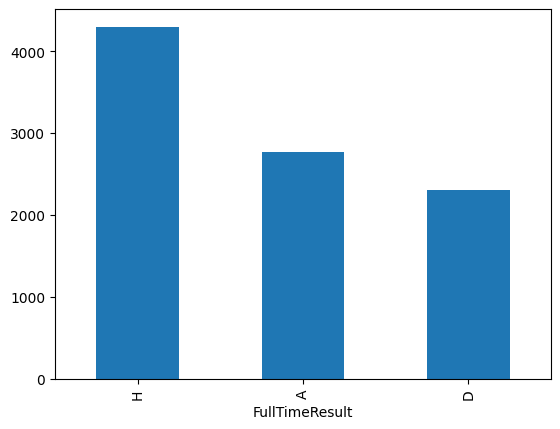

In [6]:
df["FullTimeResult"].value_counts().plot(kind="bar")
plt.show()


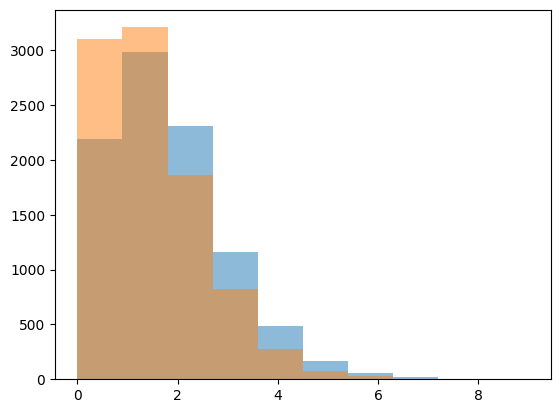

In [7]:

home_goals = df["FullTimeHomeGoals"]
away_goals = df["FullTimeAwayGoals"]
plt.hist(home_goals, bins=10, alpha=0.5)
plt.hist(away_goals, bins=10, alpha=0.5)
plt.show()


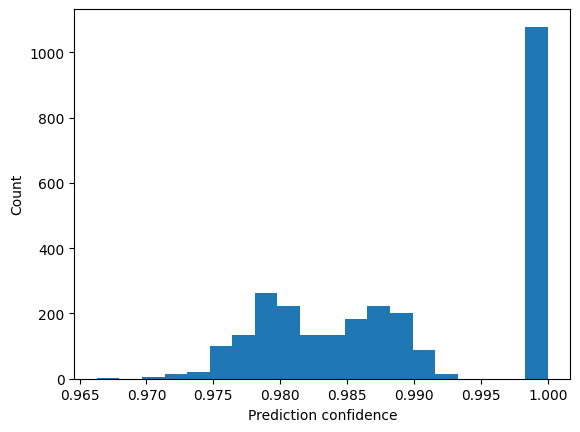

Accuracy:  1.0


,FullTimeHomeGoals,FullTimeAwayGoals,HomeShots,AwayShots,HomeShotsOnTarget,AwayShotsOnTarget,Actual,Predicted
2260,1,1,12,10,6,5,D,D
4429,2,1,15,9,9,5,H,H
4423,4,0,24,10,16,4,H,H
2246,1,1,8,10,4,4,D,D
6070,0,0,9,11,5,4,D,D


In [9]:
df_ml = df[["FullTimeHomeGoals","FullTimeAwayGoals","HomeShots","AwayShots","HomeShotsOnTarget","AwayShotsOnTarget","FullTimeResult"]].dropna()
X = df_ml.drop("FullTimeResult", axis=1)
y = df_ml["FullTimeResult"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
preds = model.predict(X_test)
accuracy_score(y_test, preds)
pd.crosstab(y_test, preds, normalize="index")
probs = model.predict_proba(X_test)
plt.hist(probs.max(axis=1), bins=20)
plt.xlabel("Prediction confidence")
plt.ylabel("Count")
plt.show()
print("Accuracy: ", accuracy_score(y_test, preds))
results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = preds
results.head()
